# 2. Dynamic multiscale DLinear improvement

The reconstruction showed that our DLinear implementation matches the paper.
We now change only the trend decomposition and keep the dataset, split,
training procedure, forecast horizon, and metrics unchanged.

## 1. Motivation

Original DLinear uses the same moving-average kernel, 25, for every Weather
variable and every input window. Weather contains variables with different
behavior, so one smoothing scale may not be suitable for all of them.

Our question is: **can DLinear improve if the trend scale adapts to both the
variable and the current input window?**

## 2. From DLinear to V1 and V2A

We use three moving averages:

- kernel 25: about 4.2 hours;
- kernel 73: about 12.2 hours;
- kernel 145: about 24.2 hours.

**V1** learns one fixed softmax mixture for each variable.

**V2A**, our final model, also changes the mixture for each input window. A
small gate receives four values for each variable: the window mean, standard
deviation, last value, and last minus first value. The gate output and a
variable-specific prior are passed through softmax, so the three weights are
positive and sum to one.

The weighted trend and remainder are still forecast by DLinear's original
two shared linear layers.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ts_project.models import (
    DLinear,
    PerVariableMultiScaleDLinear,
    DynamicPerVariableMultiScaleDLinear,
)

RESULT_ROOT = PROJECT_ROOT / "results" / "dlinear" / "weather" / "horizon_096"

## 3. Model size and a quick implementation check

In [2]:
models = {
    "DLinear": DLinear(input_length=336, prediction_length=96, channels=21),
    "V1": PerVariableMultiScaleDLinear(input_length=336, prediction_length=96, channels=21),
    "V2A": DynamicPerVariableMultiScaleDLinear(input_length=336, prediction_length=96, channels=21),
}
parameter_comparison = pd.DataFrame(
    {
        "Parameters": {
            name: sum(p.numel() for p in model.parameters())
            for name, model in models.items()
        }
    }
)
dlinear_parameters = parameter_comparison.loc["DLinear", "Parameters"]
parameter_comparison["Added vs DLinear"] = (
    parameter_comparison["Parameters"] - dlinear_parameters
)
parameter_comparison["Relative increase vs DLinear (%)"] = 100 * (
    parameter_comparison["Added vs DLinear"] / dlinear_parameters
)
parameter_comparison

,Parameters,Added vs DLinear,Relative increase vs DLinear (%)
DLinear,64704,0,0.000000
V1,64767,63,0.097366
V2A,64834,130,0.200915


In [3]:
example = torch.randn(2, 336, 21)
weights = models["V2A"].scale_weights(example)

print("Forecast shape:", tuple(models["V2A"](example).shape))
print("Weight shape:", tuple(weights.shape))
print("Smallest weight:", weights.min().item())
print("Largest error in weight sums:", (weights.sum(dim=-1) - 1).abs().max().item())

Forecast shape: (2, 96, 21)
Weight shape: (2, 21, 3)
Smallest weight: 0.3333333432674408
Largest error in weight sums: 0.0


V1 adds only 63 parameters, about 0.10% more than DLinear. V2A adds 130
parameters, about 0.20% more than DLinear. The check above also confirms
that every sample and variable receives three valid scale weights.

## 4. Validation-based selection

We first compared V1 and V2A on validation data using seeds 2021, 2022, and
2023. Both models used the same split, scaler, optimizer, loss, early stopping,
and metrics as the reconstruction. Test data was not used to choose between
V1 and V2A.

In [4]:
validation = pd.read_csv(RESULT_ROOT / "validation_by_seed.csv")
validation

,seed,model,val_mse,val_mae,best_epoch,parameters
0,2021,V1 static multiscale,0.400249,0.294227,8,64767
1,2021,V2A dynamic multiscale,0.390399,0.289043,6,64834
2,2022,V1 static multiscale,0.399301,0.294250,5,64767
3,2022,V2A dynamic multiscale,0.388505,0.289105,5,64834
4,2023,V1 static multiscale,0.399240,0.293738,9,64767
5,2023,V2A dynamic multiscale,0.388321,0.288296,9,64834


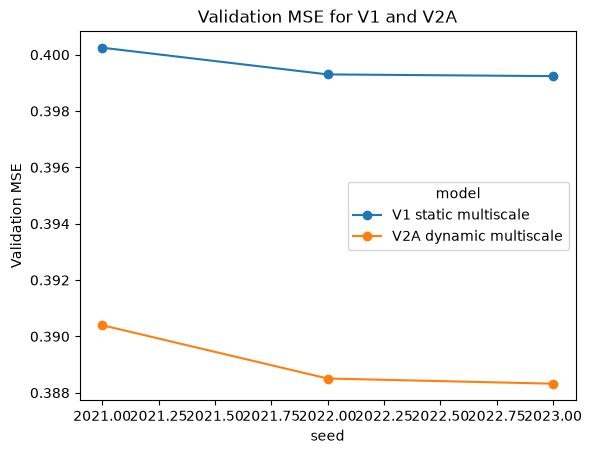

In [5]:
validation.pivot(index="seed", columns="model", values="val_mse").plot(
    marker="o",
    ylabel="Validation MSE",
    title="Validation MSE for V1 and V2A",
)
plt.show()

V2A improves validation MSE and MAE for all three seeds, so we selected it
as the final architecture before evaluating its test checkpoints.

## 5. Final test results

In [6]:
test_by_seed = pd.read_csv(RESULT_ROOT / "test_by_seed.csv")
test_summary = pd.read_csv(RESULT_ROOT / "test_summary.csv")
display(test_by_seed)
display(test_summary)

,seed,model,test_mse,test_mae,parameters
0,2021,DLinear,0.174205,0.233328,64704
1,2021,V1 static multiscale,0.167234,0.228547,64767
2,2021,V2A dynamic multiscale,0.164952,0.223527,64834
3,2022,DLinear,0.175208,0.236754,64704
4,2022,V1 static multiscale,0.167883,0.230407,64767
5,2022,V2A dynamic multiscale,0.165861,0.226255,64834
6,2023,DLinear,0.174499,0.234509,64704
7,2023,V1 static multiscale,0.167048,0.228346,64767
8,2023,V2A dynamic multiscale,0.165394,0.224983,64834


,model,test_mse_mean,test_mse_std,test_mae_mean,test_mae_std,mse_wins_vs_dlinear,mae_wins_vs_dlinear
0,DLinear,0.174638,0.000516,0.234864,0.001741,NaN,NaN
1,V1 static multiscale,0.167388,0.000438,0.229100,0.001136,3/3,3/3
2,V2A dynamic multiscale,0.165403,0.000455,0.224922,0.001365,3/3,3/3


In [7]:
final_comparison = pd.DataFrame(
    [
        {"Model": "Paper DLinear", "MSE": 0.176, "MAE": 0.237, "Parameters": np.nan},
        {"Model": "Seasonal naive", "MSE": 0.3167066, "MAE": 0.2879560, "Parameters": 0},
        {"Model": "Our DLinear", "MSE": 0.1746375, "MAE": 0.2348639, "Parameters": 64704},
        {"Model": "V1 static multiscale", "MSE": 0.1673884, "MAE": 0.2290998, "Parameters": 64767},
        {"Model": "V2A dynamic multiscale", "MSE": 0.1654027, "MAE": 0.2249218, "Parameters": 64834},
    ]
)
final_comparison["RMSE"] = np.sqrt(final_comparison["MSE"])
final_comparison

,Model,MSE,MAE,Parameters,RMSE
0,Paper DLinear,0.176000,0.237000,NaN,0.419524
1,Seasonal naive,0.316707,0.287956,0.0,0.562767
2,Our DLinear,0.174638,0.234864,64704.0,0.417897
3,V1 static multiscale,0.167388,0.229100,64767.0,0.409131
4,V2A dynamic multiscale,0.165403,0.224922,64834.0,0.406697


Across the three paired seeds, V2A reduces test MSE by about 5.29% and MAE
by about 4.23% compared with reconstructed DLinear. It wins on both metrics
for all three seeds.

## 6. Discussion and limitations

The main result supports our hypothesis on Weather: variable-specific scales
help, and adapting them to the current window helps further. The improvement
is also small in model size and easy to interpret.

The result should not be described as a universal improvement. Earlier tests
showed smaller gains on Electricity and ETTh1. We also tried several ideas on
the same Weather validation split, so some validation-selection bias is
possible. V1's test result was already known before V2A was designed, although
V2A itself was frozen using validation results before its test evaluation.